In [3]:
import pandas as pd
df = pd.read_csv('cleaned_data.csv')
df_balanced = df.copy()  # Work on a copy to keep the original safe


In [16]:
# Identify categorical columns (non-numeric)
categorical_cols = df_balanced.select_dtypes(include=['object']).columns.tolist()

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows
df_encoded.head()

,HasPay,Sum of Employees,Sum of APA License utilization,AP Automation,Sum of ACV (USD),Sum of Number of Locations,ActivatedModules,ActiveSubsidiaries,ActiveUsers,AvgCommentsPerDocument,...,"Account Description_landsbanken Abp is a company that operates in the Financial Services industry. It employs 501-1,000 people and has $100M-$250M of revenue. The company is headquartered in Finland.","Account Description_m4 gruppen AB is active in five business areas: Construction Distribution Industry Environment & Recycling Tank & Bulk The company was founded 2010 through a merger of four well established logistics companies in Mlardalen, Sweden. The company he",Account Description_omkostnad kredit Varu,"Account Description_uk.idc.com is a company that operates in the Internet industry. It employs 6-10 people and has $1M-$5M of revenue. The company is headquartered in London, Greater London, United Kingdom.","Account Description_Åkerströms Björbo AB is an international company founded in 1918 that develops, produces, markets, and services high-quality and robust products for remote control of industrial cranes, doors and mobile applications. We have more than 50 years of experie","Account Description_Östenssons Livs AB is a company that operates in the Retail industry. It employs 101-250 people and has $1M-$5M of revenue. The company is headquartered in Motala, OEstergoetland, Sweden.",Account Description_�vertagen av Bj�rn G okt 2012,"Account Description_�vertagen av Bj�rn G okt 2012 Metalstructures har IFS och ska uppgradera 2012-2013 Bulten Har Lawson M3, nyimplementerat 2011-2012 Koncernmoder, aff�rerna sker med ovan bolag",Account Description_�vertagen fr Fredrik E 20140211 De b?da skripten heter: TillSkarpt.vbs (styr mot Mflow databsen) TillTest.vbs (Styr mot Mflowtest76 databasen,"Account Description_�vertagen fr Malin Marcko, 20140214 Omkostnadsfakturor. PDF via mapp-import."
0,0,240.0,38.0,True,25680.10,6.0,6,7,59,1.705660,...,False,False,False,False,False,False,False,False,False,False
1,0,118.0,45.0,True,4111.88,8.0,7,4,227,1.903382,...,False,False,False,False,False,False,False,False,False,False
2,0,35.0,67.0,True,0.00,2.0,8,2,29,NaN,...,False,False,False,False,False,False,False,False,False,False
3,0,6200.0,100.0,True,144999.96,7.0,7,3,336,1.916706,...,False,False,False,False,False,False,False,False,False,False
4,0,151.0,45.0,True,131655.44,1.0,7,15,444,1.568859,...,False,False,False,False,False,False,False,False,False,False


Undersampling the Majority Class (HasPay = 0)

In [5]:
!pip install imbalanced-learn

  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/9d/41/721fec82606242a2072ee909086ff918dfad7d0199a9dfd4928df9c72494/imbalanced_learn-0.13.0-py3-none-any.whl.metadata
  Obtaining dependency information for scipy<2,>=1.10.1 from https://files.pythonhosted.org/packages/b9/8b/7ec1832b09dbc88f3db411f8cdd47db04505c4b72c99b11c920a8f0479c3/scipy-1.15.2-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.8 kB 667.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 647.7 kB/s eta 0:00:00
  Obtaining dependency information for scikit-learn<2,>=1.3.2 from https://files.pythonhosted.org/packages/a1/a6/c5b78606743a1f28eae8f11973de6613a5ee87366796583fb74c67d54939/scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency informatio


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

def split_features_target(df_encoded, target_column="HasPay"):
    """Splits dataframe into features (X) and target variable (y)."""
    X = df_encoded.drop(columns=[target_column])
    y = df_encoded[target_column]
    return X, y

def check_class_distribution(y):
    """Prints the class distribution of the target variable."""
    counter = Counter(y)
    print(f"Class distribution: {counter}")

def apply_undersampling(X, y):
    """Applies Random Undersampling to balance the dataset."""
    undersampler = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = undersampler.fit_resample(X, y)
    return X_resampled, y_resampled

In [20]:
# Load Data (Assuming df is already loaded)
X, y = split_features_target(df_encoded)

# Check Initial Distribution
check_class_distribution(y)

# Apply Undersampling
X_resampled, y_resampled = apply_undersampling(X, y)

# Check New Distribution
check_class_distribution(y_resampled)


Class distribution: Counter({0: 984, 1: 71})
Class distribution: Counter({0: 71, 1: 71})


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def train_and_evaluate(X, y):
    """Splits the data, trains a model, and evaluates its performance."""

    # Step 1: Split into Training and Test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 2: Train a model (Random Forest)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Step 3: Make predictions
    y_pred = model.predict(X_test)

    # Step 4: Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return model

# Run evaluation on the undersampled dataset
model = train_and_evaluate(X_resampled, y_resampled)


Accuracy: 0.7931
Precision: 0.7857
Recall: 0.7857
F1 Score: 0.7857

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        15
           1       0.79      0.79      0.79        14

    accuracy                           0.79        29
   macro avg       0.79      0.79      0.79        29
weighted avg       0.79      0.79      0.79        29



In [66]:
def get_top_10_feature_importances(model, X):
    """Extracts and prints the top 10 feature importances from the trained model."""
    importances = model.feature_importances_
    feature_names = X.columns
    # Create a DataFrame to show the importance of each feature
    feature_importances = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

    # Display the top 10 features
    print("\nTop 10 Feature Importances:\n", feature_importances.head(10))

# After training the model
model = train_and_evaluate(X_resampled, y_resampled)

# Get and display top 10 feature importances
get_top_10_feature_importances(model, X_resampled)




Accuracy: 0.7931
Precision: 0.8333
Recall: 0.7143
F1 Score: 0.7692

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.87      0.81        15
         1.0       0.83      0.71      0.77        14

    accuracy                           0.79        29
   macro avg       0.80      0.79      0.79        29
weighted avg       0.80      0.79      0.79        29


Top 10 Feature Importances:
                                     Feature  Importance
5                          ActivatedModules    0.069272
13                        DistinctLanguages    0.039895
3                          Sum of ACV (USD)    0.037459
1375  Medius Territory_Medius North America    0.035743
11                       AvgLinesPerInvoice    0.032014
12                           AvgOverdueDays    0.030957
8                    AvgCommentsPerDocument    0.030856
15                    TotalArchivedInvoices    0.029522
16                      OverdueInvoiceCount    

In [67]:
def apply_purchase_probability(model, X):
    """Applies the trained model to predict the likelihood of each APA tenant purchasing Pay."""
    # Get probabilities for both classes (class 0 and class 1)
    probabilities = model.predict_proba(X)

    # Extract the probabilities for class 1 (tenant purchasing Pay)
    purchase_probabilities = probabilities[:, 1]

    # Add the probabilities as a new column to the original features DataFrame
    X_with_scores = X.copy()
    X_with_scores['Purchase_Probability'] = purchase_probabilities

    return X_with_scores

# After training the model
model = train_and_evaluate(X_resampled, y_resampled)

# Apply the model to get the purchase probabilities for each tenant
X_with_scores = apply_purchase_probability(model, X_resampled)

# Display the first few rows with the probability scores
print(X_with_scores[['Purchase_Probability']].head())


Accuracy: 0.7931
Precision: 0.8333
Recall: 0.7143
F1 Score: 0.7692

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.87      0.81        15
         1.0       0.83      0.71      0.77        14

    accuracy                           0.79        29
   macro avg       0.80      0.79      0.79        29
weighted avg       0.80      0.79      0.79        29

     Purchase_Probability
652                  0.10
482                  0.63
779                  0.32
467                  0.13
296                  0.06


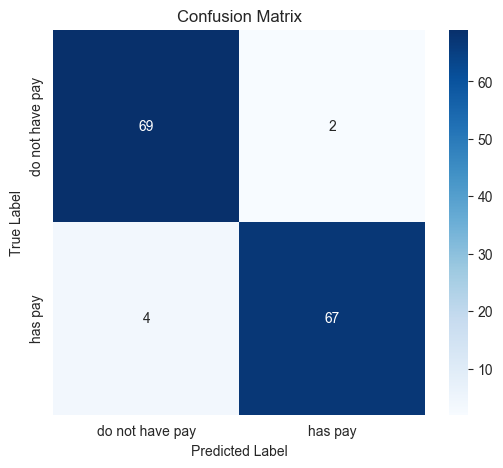

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred):
    """Generates and plots a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    # Plot the heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["do not have pay", "has pay"], yticklabels=["do not have pay", "has pay"])

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Generate predictions using the trained model
y_pred = model.predict(X_resampled)

# Plot the confusion matrix
plot_confusion_matrix(y_resampled, y_pred)
